<a href="https://colab.research.google.com/github/Naditya206/PCVK/blob/main/Week9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Cell 1 — Install & import, mount Google Drive (Colab)

In [1]:
# Cell 1 - instalasi (jika diperlukan) dan import library dasar, mount drive
# Jalankan ini pertama kali di Colab

# Jika scikit-learn belum ada (biasanya sudah ada di Colab), uncomment:
# !pip install -q scikit-learn

from google.colab import drive
drive.mount('/content/drive')  # jalankan untuk mengakses Drive; login akan diminta

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
%matplotlib inline
import os

print("Libraries loaded. Current working dir:", os.getcwd())

Mounted at /content/drive
Libraries loaded. Current working dir: /content


Cell 2 — Helper: fungsi untuk menampilkan gambar (RGB & grayscale)

In [2]:
# Cell 2 - helper functions untuk menampilkan gambar
from google.colab.patches import cv2_imshow

def show_gray(img, title='', figsize=(6,6)):
    plt.figure(figsize=figsize)
    if len(img.shape)==3:
        img_ = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    else:
        img_ = img
    plt.imshow(img_, cmap='gray')
    plt.title(title); plt.axis('off')
    plt.show()

def show_rgb_from_bgr(bgr_img, title='', figsize=(6,6)):
    rgb = cv.cvtColor(bgr_img, cv.COLOR_BGR2RGB)
    plt.figure(figsize=figsize)
    plt.imshow(rgb)
    plt.title(title); plt.axis('off')
    plt.show()


Cell 3 — Contoh Global Threshold (5 mode) dengan threshold = 170

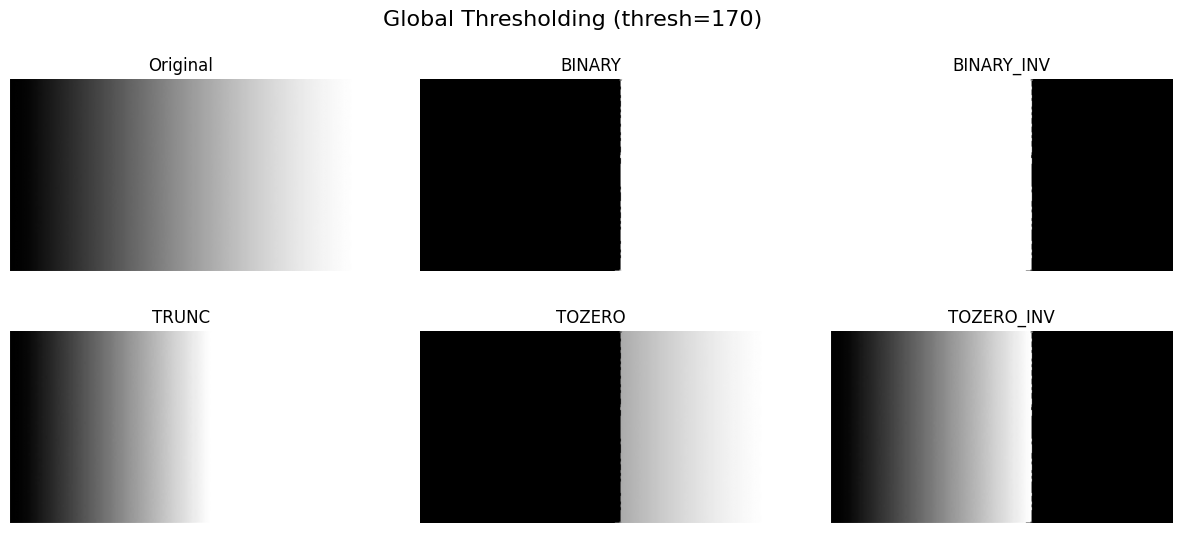

In [3]:
# Cell 3 - Global Threshold contoh (BINARY, BINARY_INV, TRUNC, TOZERO, TOZERO_INV)
image_path = '/content/drive/MyDrive/PCVK/Images/gradient.jpg'  # ganti sesuai lokasi
img = cv.imread(image_path, cv.IMREAD_GRAYSCALE)
if img is None:
    raise FileNotFoundError(f"Image not found: {image_path}")

thresh_val = 170
ret, th_binary = cv.threshold(img, thresh_val, 255, cv.THRESH_BINARY)
ret, th_bin_inv = cv.threshold(img, thresh_val, 255, cv.THRESH_BINARY_INV)
ret, th_trunc = cv.threshold(img, thresh_val, 255, cv.THRESH_TRUNC)
ret, th_tozero = cv.threshold(img, thresh_val, 255, cv.THRESH_TOZERO)
ret, th_tozero_inv = cv.threshold(img, thresh_val, 255, cv.THRESH_TOZERO_INV)

titles = ['Original','BINARY','BINARY_INV','TRUNC','TOZERO','TOZERO_INV']
images = [img, th_binary, th_bin_inv, th_trunc, th_tozero, th_tozero_inv]

plt.figure(figsize=(15,6))
for i, (im, t) in enumerate(zip(images, titles)):
    plt.subplot(2,3,i+1)
    plt.imshow(im, cmap='gray')
    plt.title(t)
    plt.axis('off')
plt.suptitle(f'Global Thresholding (thresh={thresh_val})', fontsize=16)
plt.show()


Cell 4 — Adaptive Threshold (Mean & Gaussian) (contoh sudoku)

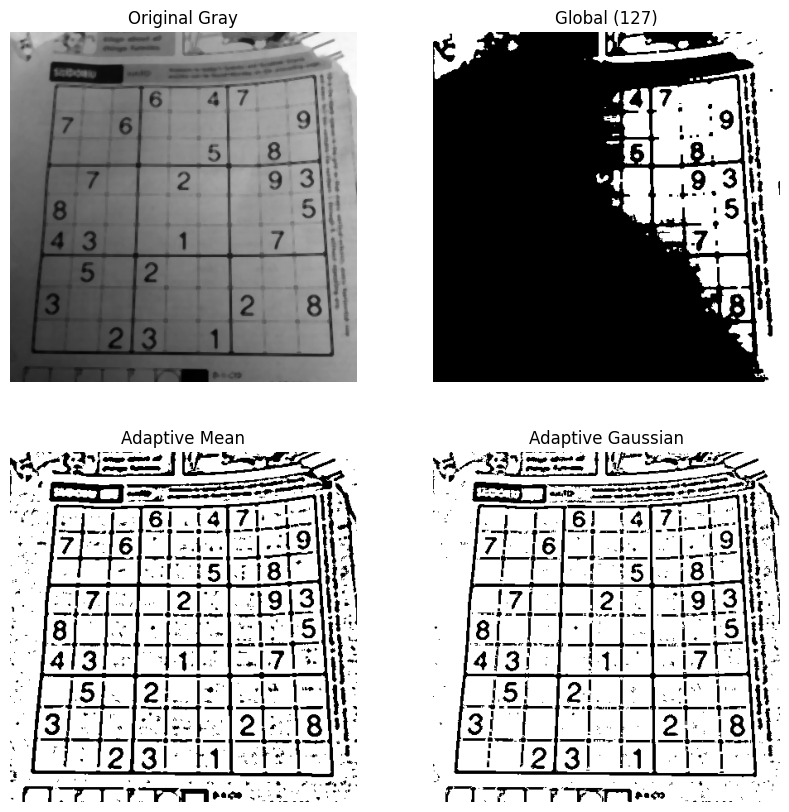

In [4]:
# Cell 4 - Adaptive Thresholding (Mean & Gaussian)
image_path = '/content/drive/MyDrive/PCVK/Images/sudoku-original.jpg'  # ganti sesuai lokasi
img_color = cv.imread(image_path)
if img_color is None:
    raise FileNotFoundError(f"Image not found: {image_path}")

gray = cv.cvtColor(img_color, cv.COLOR_BGR2GRAY)
# optional median blur
gray_med = cv.medianBlur(gray, 5)

thresh = 127
ret, th_global = cv.threshold(gray_med, thresh, 255, cv.THRESH_BINARY)
th_mean = cv.adaptiveThreshold(gray_med, 255, cv.ADAPTIVE_THRESH_MEAN_C, cv.THRESH_BINARY, 11, 2)
th_gauss = cv.adaptiveThreshold(gray_med, 255, cv.ADAPTIVE_THRESH_GAUSSIAN_C, cv.THRESH_BINARY, 11, 2)

titles = ['Original Gray','Global (127)','Adaptive Mean','Adaptive Gaussian']
imgs = [gray_med, th_global, th_mean, th_gauss]

plt.figure(figsize=(10,10))
for i,(im,t) in enumerate(zip(imgs,titles)):
    plt.subplot(2,2,i+1)
    plt.imshow(im, cmap='gray'); plt.title(t); plt.axis('off')
plt.show()


Cell 5 — Otsu's Threshold (dengan OpenCV) & histogram visual

/tmp/ipython-input-1961091565.py:13: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(blur.ravel(),256,[0,256]); plt.title('Histogram (blur)')


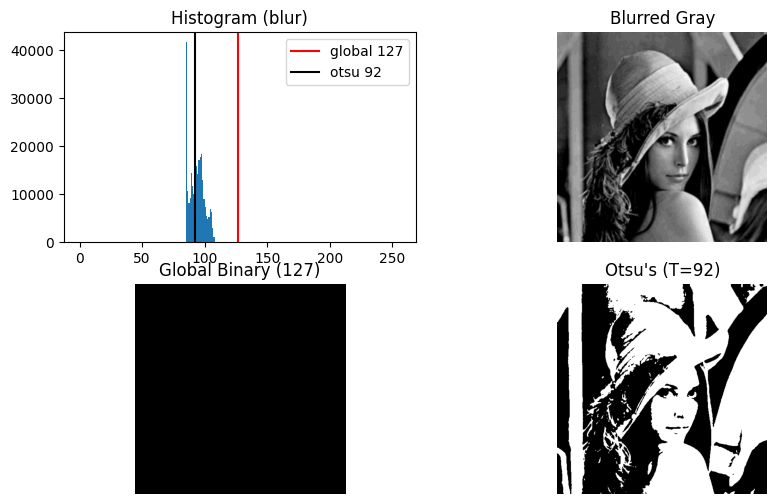

In [5]:
# Cell 5 - Otsu dengan OpenCV (contoh lena_gs_lc2.jpg)
image_path = '/content/drive/MyDrive/PCVK/Images/lena_gs_lc2.jpg'  # ganti
img = cv.imread(image_path, cv.IMREAD_GRAYSCALE)
if img is None:
    raise FileNotFoundError(f"Image not found: {image_path}")

blur = cv.GaussianBlur(img, (5,5), 0)
ret_global, th_global = cv.threshold(blur, 127, 255, cv.THRESH_BINARY)
ret_otsu, th_otsu = cv.threshold(blur, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

plt.figure(figsize=(10,6))
plt.subplot(2,2,1)
plt.hist(blur.ravel(),256,[0,256]); plt.title('Histogram (blur)')
plt.axvline(x=127, color='red', label='global 127')
plt.axvline(x=ret_otsu, color='black', label=f"otsu {ret_otsu:.0f}"); plt.legend()

plt.subplot(2,2,2); plt.imshow(blur, cmap='gray'); plt.title('Blurred Gray'); plt.axis('off')
plt.subplot(2,2,3); plt.imshow(th_global, cmap='gray'); plt.title('Global Binary (127)'); plt.axis('off')
plt.subplot(2,2,4); plt.imshow(th_otsu, cmap='gray'); plt.title(f"Otsu's (T={ret_otsu:.0f})"); plt.axis('off')
plt.show()


Cell 6 — Otsu's threshold manual (tanpa library) — hitung within-class variance dan pilih T

Otsu manual selected threshold = 172


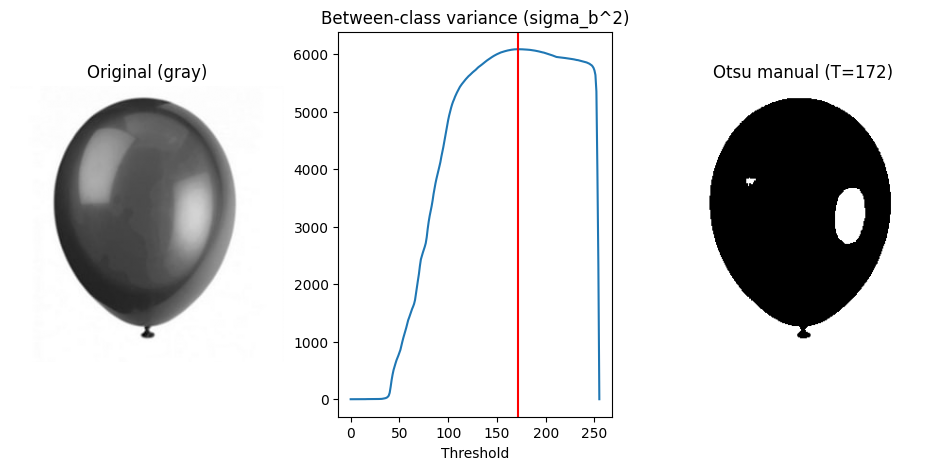

In [6]:
# Cell 6 - Implementasi Otsu manual (tanpa cv.THRESH_OTSU)
# Menggunakan image balloon.jpg (soal praktikum meminta membandingkan)
image_path = '/content/drive/MyDrive/PCVK/Images/balloon.jpg'  # ganti sesuai drive
img = cv.imread(image_path, cv.IMREAD_GRAYSCALE)
if img is None:
    raise FileNotFoundError(f"Image not found: {image_path}")

# histogram normalized
hist = cv.calcHist([img], [0], None, [256], [0,256]).flatten()
total = hist.sum()
prob = hist / total

# precompute cumulative sums for efficiency
omega = np.cumsum(prob)              # weight w0(t)
mu = np.cumsum(prob * np.arange(256))# cumulative mean up to t
mu_total = mu[-1]

# between-class variance sigma_bsq for each t
sigma_b_sq = (mu_total * omega - mu)**2 / (omega * (1 - omega) + 1e-12)

# select T that maximizes between-class variance (equiv. minimize within-class)
T_best = np.nanargmax(sigma_b_sq)
# produce binary image using T_best
_, th_manual = cv.threshold(img, T_best, 255, cv.THRESH_BINARY)

print(f"Otsu manual selected threshold = {T_best}")

plt.figure(figsize=(12,5))
plt.subplot(1,3,1); plt.imshow(img, cmap='gray'); plt.title('Original (gray)'); plt.axis('off')
plt.subplot(1,3,2); plt.plot(sigma_b_sq); plt.title('Between-class variance (sigma_b^2)'); plt.axvline(T_best, color='red'); plt.xlabel('Threshold')
plt.subplot(1,3,3); plt.imshow(th_manual, cmap='gray'); plt.title(f"Otsu manual (T={T_best})"); plt.axis('off')
plt.show()


Cell 7 — Perbandingan Otsu tanpa/ dengan Gaussian (noisy example)

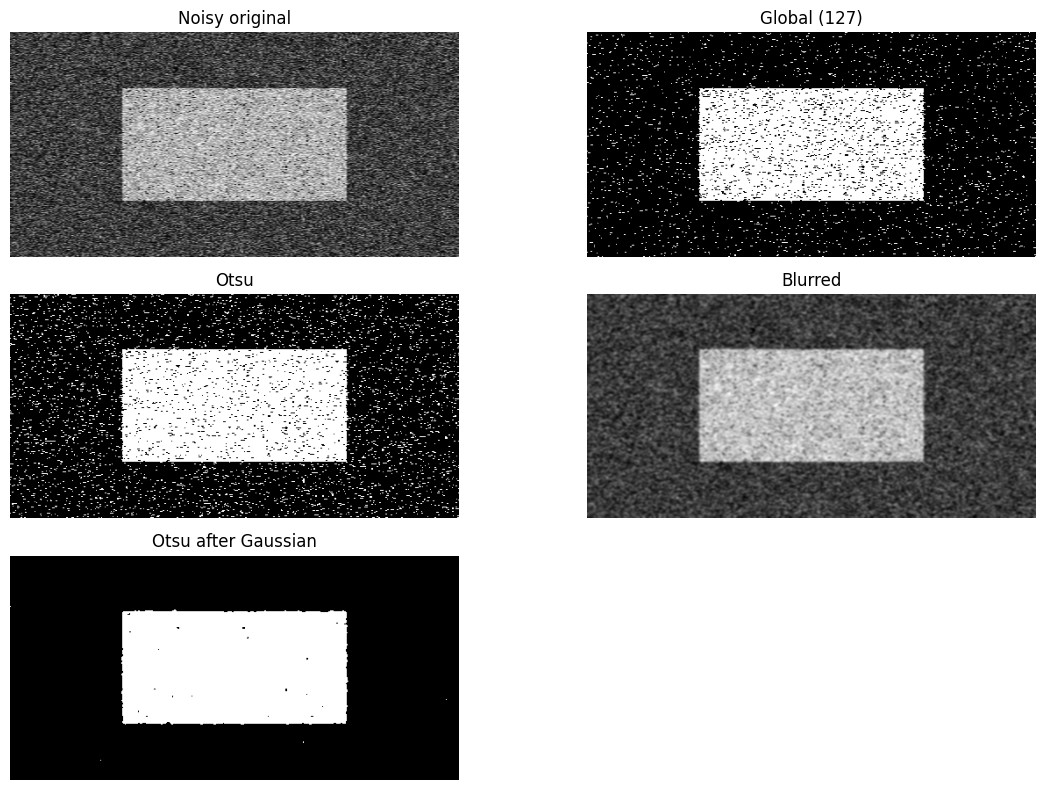

In [7]:
# Cell 7 - Otsu on noisy image (menunjukkan efek gaussian filter)
image_path = '/content/drive/MyDrive/PCVK/Images/noisy2.png'
img = cv.imread(image_path, cv.IMREAD_GRAYSCALE)
if img is None:
    raise FileNotFoundError(f"Image not found: {image_path}")

ret1, th1 = cv.threshold(img, 127, 255, cv.THRESH_BINARY)
ret2, th2 = cv.threshold(img, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)
blur = cv.GaussianBlur(img,(5,5),0)
ret3, th3 = cv.threshold(blur, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

images = [img, th1, th2, blur, th3]
titles = ['Noisy original','Global (127)','Otsu','Blurred','Otsu after Gaussian']

plt.figure(figsize=(12,8))
for i,(im,t) in enumerate(zip(images,titles)):
    plt.subplot(3,2,i+1); plt.imshow(im, cmap='gray'); plt.title(t); plt.axis('off')
plt.tight_layout()
plt.show()


Cell 8 — K-Means segmentation (contoh jungle.png) & ubah satu cluster jadi hitam (dari modul)

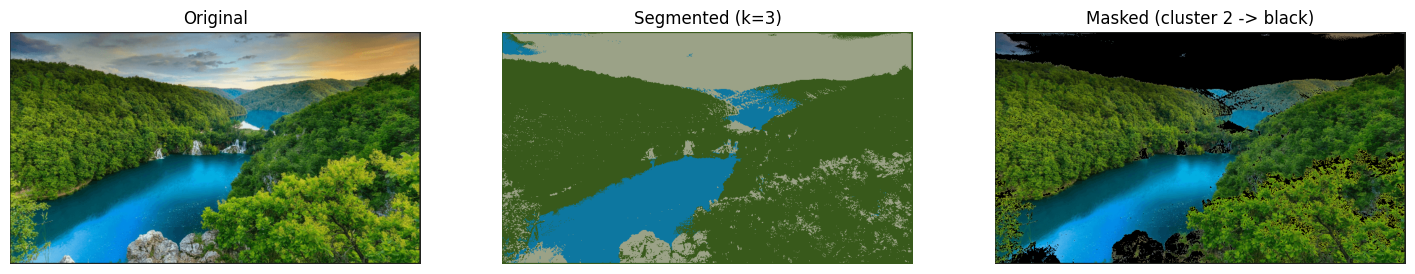

In [8]:
# Cell 8 - KMeans segmentation & masking cluster (contoh jungle.png)
image_path = '/content/drive/MyDrive/PCVK/Images/jungle.png'
img = cv.imread(image_path)
if img is None:
    raise FileNotFoundError(f"Image not found: {image_path}")

img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
pixel_vals = img_rgb.reshape((-1,3)).astype(np.float32)

k = 3
kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(pixel_vals)
centers = kmeans.cluster_centers_.astype(np.uint8)

segmented = centers[labels].reshape(img_rgb.shape)

# Mask: ubah cluster index 2 menjadi hitam (contoh tugas di modul)
cluster_to_mask = 2
masked = img_rgb.copy().reshape((-1,3))
masked[labels == cluster_to_mask] = [0,0,0]
masked = masked.reshape(img_rgb.shape)

plt.figure(figsize=(18,6))
plt.subplot(1,3,1); plt.imshow(img_rgb); plt.title('Original'); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(segmented); plt.title('Segmented (k=3)'); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(masked); plt.title(f'Masked (cluster {cluster_to_mask} -> black)'); plt.axis('off')
plt.show()


Cell 9 — TUGAS 3: Histogram foreground only (gunakan tobacco.jpg)

Cluster centers (RGB):
 [[ 94 119  22]
 [253 251 250]
 [250 206   2]
 [200  86  79]
 [169  18  15]
 [191 181 133]]


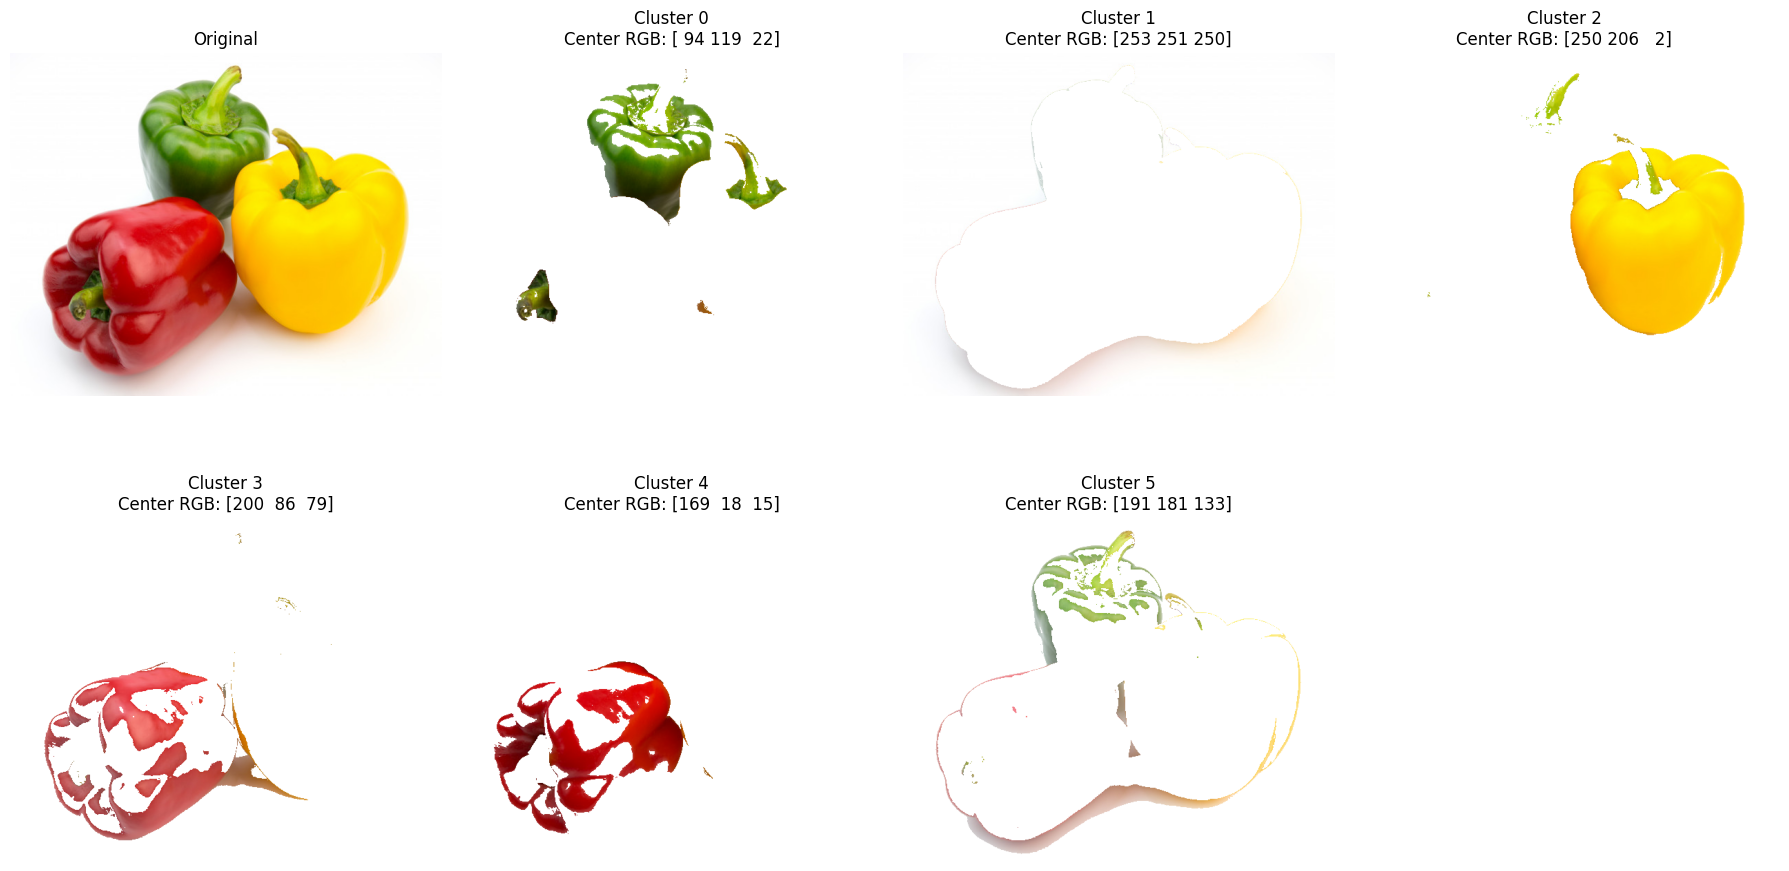


Jumlah cluster: 6
Keterangan:
- Setiap 'Cluster' menunjukkan area berbeda pada gambar sesuai warna dominannya.
- Centers di atas menunjukkan nilai RGB rata-rata tiap cluster.
- Anda dapat memilih cluster mana yang paling mirip dengan warna target (merah, hijau, kuning, putih, dll)
  dengan membandingkan nilai centers dengan warna referensi.



In [9]:
# Cell 10 (K-Means dengan 6 cluster) - Segmentasi penuh peppers.jpg

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# === BACA CITRA ===
image_path = '/content/drive/MyDrive/PCVK/Images/peppers.jpg'
img_bgr = cv.imread(image_path)
if img_bgr is None:
    raise FileNotFoundError(f"Image not found: {image_path}")

# Konversi ke RGB
img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)
pixel_vals = img_rgb.reshape((-1,3)).astype(np.float32)

# === K-MEANS CLUSTERING ===
k = 6  # jumlah cluster
kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(pixel_vals)
centers = kmeans.cluster_centers_.astype(np.uint8)

print("Cluster centers (RGB):\n", centers)

# === BENTUK ULANG KE CITRA SEGMENTED ===
segmented_img = centers[labels].reshape(img_rgb.shape)

# === TAMPILKAN CLUSTER MENGGUNAKAN MASK TIAP CLUSTER ===
plt.figure(figsize=(18,10))
plt.subplot(2,4,1)
plt.imshow(img_rgb)
plt.title('Original')
plt.axis('off')

# tampilkan tiap cluster
for i in range(k):
    mask = (labels == i).reshape(img_rgb.shape[:2])
    cluster_img = np.ones_like(img_rgb, dtype=np.uint8) * 255  # background putih
    cluster_img[mask] = img_rgb[mask]
    plt.subplot(2,4,i+2)
    plt.imshow(cluster_img)
    plt.title(f'Cluster {i}\nCenter RGB: {centers[i]}')
    plt.axis('off')

plt.tight_layout()
plt.show()

# === PENJELASAN ===
print(f"""
Jumlah cluster: {k}
Keterangan:
- Setiap 'Cluster' menunjukkan area berbeda pada gambar sesuai warna dominannya.
- Centers di atas menunjukkan nilai RGB rata-rata tiap cluster.
- Anda dapat memilih cluster mana yang paling mirip dengan warna target (merah, hijau, kuning, putih, dll)
  dengan membandingkan nilai centers dengan warna referensi.
""")


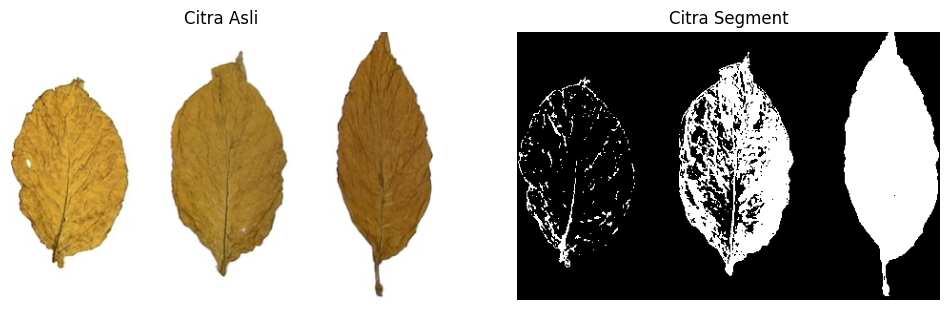

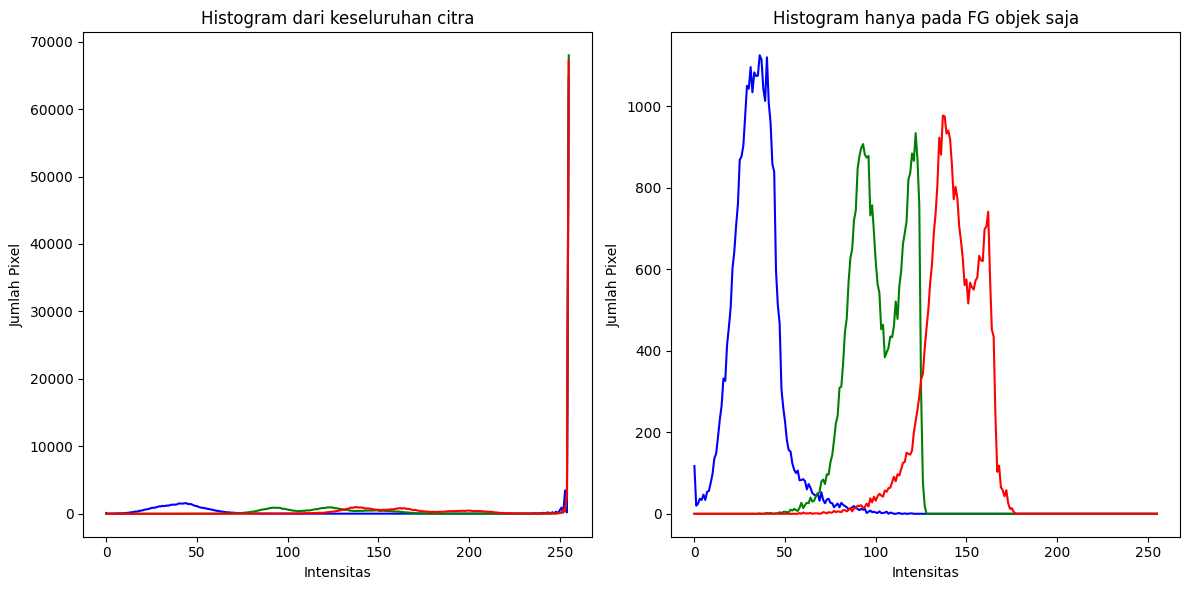

In [10]:
# Cell 9 (revisi lengkap) - Histogram foreground (tobacco.jpg) seperti di modul
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# === BACA CITRA ===
image_path = '/content/drive/MyDrive/PCVK/Images/tobacco.jpg'
img = cv.imread(image_path)
if img is None:
    raise FileNotFoundError(f"Image not found: {image_path}")

# === KONVERSI GRAYSCALE & BUAT MASK SEGMENTASI ===
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
# Threshold untuk dapatkan daun sebagai foreground putih
ret, mask = cv.threshold(gray, 127, 255, cv.THRESH_BINARY_INV)
# Catatan: jika hasil terbalik (daun hitam, background putih), ubah ke cv.THRESH_BINARY saja.

# === TAMPILKAN CITRA ASLI & MASK ===
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title('Citra Asli'); plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(mask, cmap='gray')
plt.title('Citra Segment'); plt.axis('off')
plt.show()

# === HISTOGRAM SELURUH CITRA (tanpa mask) ===
colors = ('b','g','r')
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
for i,col in enumerate(colors):
    hist_full = cv.calcHist([img],[i],None,[256],[0,256])
    plt.plot(hist_full, color=col)
plt.title('Histogram dari keseluruhan citra')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah Pixel')

# === HISTOGRAM HANYA PADA FOREGROUND (mask putih) ===
plt.subplot(1,2,2)
for i,col in enumerate(colors):
    hist_mask = cv.calcHist([img],[i],mask,[256],[0,256])
    plt.plot(hist_mask, color=col)
plt.title('Histogram hanya pada FG objek saja')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah Pixel')

plt.tight_layout()
plt.show()


Cell 10 — TUGAS 6: Segment warna kuning saja (peppers.jpg) menggunakan KMeans

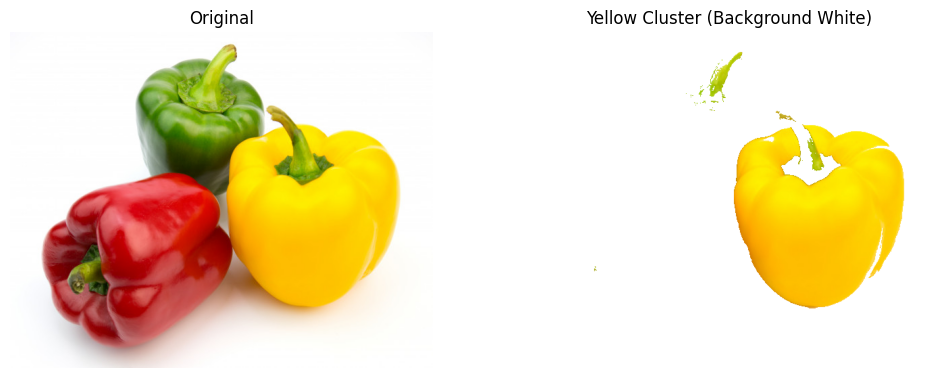


Kendala:
- Warna kuning memiliki variasi hue dan intensitas sehingga kadang terbagi ke beberapa cluster.
- KMeans bekerja di ruang RGB; perbedaan pencahayaan bisa memecah area kuning ke beberapa cluster.
Solusi:
- Gunakan ruang warna HSV dengan threshold pada hue kuning agar hasil lebih stabil terhadap pencahayaan.



In [11]:
# Cell 10 (versi tanpa tampilan cluster centers) - Segment warna kuning di peppers.jpg, background putih

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# === BACA CITRA ===
image_path = '/content/drive/MyDrive/PCVK/Images/peppers.jpg'
img_bgr = cv.imread(image_path)
if img_bgr is None:
    raise FileNotFoundError(f"Image not found: {image_path}")

img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)
pixel_vals = img_rgb.reshape((-1,3)).astype(np.float32)

# === K-MEANS CLUSTERING ===
k = 6  # jumlah cluster
kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(pixel_vals)
centers = kmeans.cluster_centers_.astype(np.uint8)

# === DEFINISI WARNA KUNING REFERENSI ===
yellow_ref = np.array([255, 255, 0])
dist_to_yellow = np.linalg.norm(centers - yellow_ref, axis=1)
yellow_cluster = np.argmin(dist_to_yellow)

# === BUAT MASK AREA KUNING ===
mask = (labels == yellow_cluster).reshape(img_rgb.shape[:2])

# === BUAT OUTPUT: BACKGROUND PUTIH, AREA KUNING ASLI ===
output = np.ones_like(img_rgb, dtype=np.uint8) * 255
output[mask] = img_rgb[mask]

# === TAMPILKAN HASIL (tanpa cluster centers) ===
plt.figure(figsize=(12,6))
plt.subplot(1,2,1); plt.imshow(img_rgb); plt.title('Original'); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(output); plt.title('Yellow Cluster (Background White)'); plt.axis('off')
plt.show()

# === PENJELASAN KENDALA ===
print("""
Kendala:
- Warna kuning memiliki variasi hue dan intensitas sehingga kadang terbagi ke beberapa cluster.
- KMeans bekerja di ruang RGB; perbedaan pencahayaan bisa memecah area kuning ke beberapa cluster.
Solusi:
- Gunakan ruang warna HSV dengan threshold pada hue kuning agar hasil lebih stabil terhadap pencahayaan.
""")


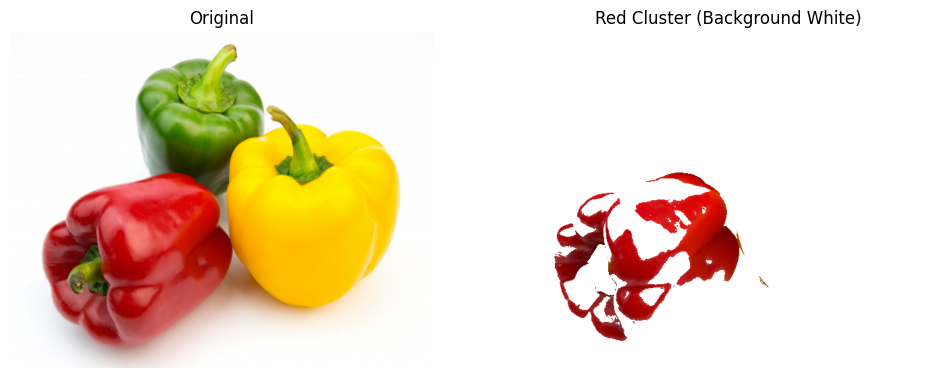


Kendala:
- Warna merah memiliki banyak variasi intensitas (terang, gelap, bayangan) sehingga kadang tersebar ke beberapa cluster.
- KMeans di ruang RGB hanya menghitung jarak numerik antar warna tanpa mempertimbangkan persepsi visual.
Solusi:
- Gunakan ruang warna HSV dan threshold rentang hue merah (misal H 0–10 & 160–180) untuk hasil lebih stabil.
- Atau tambahkan jumlah cluster (k > 6) agar warna merah terang dan gelap dapat terpisah lebih baik.



In [12]:
# Cell 10 (versi tanpa cluster centers) - Segment warna merah di peppers.jpg, background putih

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# === BACA CITRA ===
image_path = '/content/drive/MyDrive/PCVK/Images/peppers.jpg'
img_bgr = cv.imread(image_path)
if img_bgr is None:
    raise FileNotFoundError(f"Image not found: {image_path}")

# konversi BGR -> RGB
img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)
pixel_vals = img_rgb.reshape((-1,3)).astype(np.float32)

# === K-MEANS CLUSTERING ===
k = 6  # jumlah cluster
kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(pixel_vals)
centers = kmeans.cluster_centers_.astype(np.uint8)

# === DEFINISI WARNA MERAH REFERENSI ===
red_ref = np.array([255, 0, 0])
dist_to_red = np.linalg.norm(centers - red_ref, axis=1)
red_cluster = np.argmin(dist_to_red)

# === BUAT MASK AREA MERAH ===
mask = (labels == red_cluster).reshape(img_rgb.shape[:2])

# === BUAT OUTPUT: BACKGROUND PUTIH, AREA MERAH ASLI ===
output = np.ones_like(img_rgb, dtype=np.uint8) * 255  # background putih
output[mask] = img_rgb[mask]

# === TAMPILKAN HASIL (tanpa cluster centers) ===
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title('Original')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(output)
plt.title('Red Cluster (Background White)')
plt.axis('off')

plt.show()

# === PENJELASAN KENDALA ===
print("""
Kendala:
- Warna merah memiliki banyak variasi intensitas (terang, gelap, bayangan) sehingga kadang tersebar ke beberapa cluster.
- KMeans di ruang RGB hanya menghitung jarak numerik antar warna tanpa mempertimbangkan persepsi visual.
Solusi:
- Gunakan ruang warna HSV dan threshold rentang hue merah (misal H 0–10 & 160–180) untuk hasil lebih stabil.
- Atau tambahkan jumlah cluster (k > 6) agar warna merah terang dan gelap dapat terpisah lebih baik.
""")


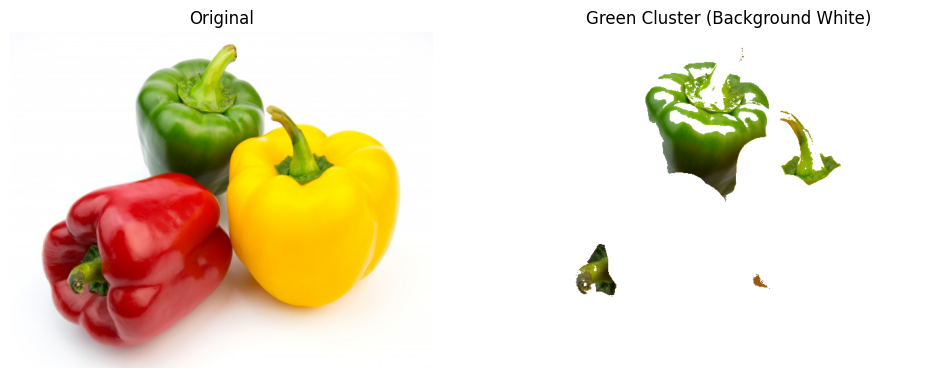


Kendala:
- Warna hijau memiliki banyak variasi tingkat kecerahan dan saturasi, terutama akibat pantulan cahaya dan bayangan.
- KMeans di ruang RGB hanya mengelompokkan berdasarkan jarak numerik antar warna, sehingga hijau gelap dan terang bisa masuk ke cluster berbeda.
Solusi:
- Gunakan ruang warna HSV dan threshold pada rentang hue hijau (H 35–85) agar lebih akurat.
- Atau tingkatkan jumlah cluster (k > 6) agar variasi hijau bisa terpisah dengan baik.



In [13]:
# Cell 10 (versi tanpa cluster centers) - Segment warna hijau di peppers.jpg, background putih

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# === BACA CITRA ===
image_path = '/content/drive/MyDrive/PCVK/Images/peppers.jpg'
img_bgr = cv.imread(image_path)
if img_bgr is None:
    raise FileNotFoundError(f"Image not found: {image_path}")

# konversi BGR -> RGB
img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)
pixel_vals = img_rgb.reshape((-1,3)).astype(np.float32)

# === K-MEANS CLUSTERING ===
k = 6  # jumlah cluster (5–8 biasanya ideal)
kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(pixel_vals)
centers = kmeans.cluster_centers_.astype(np.uint8)

# === DEFINISI WARNA HIJAU REFERENSI ===
green_ref = np.array([0, 255, 0])  # RGB hijau murni
dist_to_green = np.linalg.norm(centers - green_ref, axis=1)
green_cluster = np.argmin(dist_to_green)

# === BUAT MASK AREA HIJAU ===
mask = (labels == green_cluster).reshape(img_rgb.shape[:2])

# === BUAT OUTPUT: BACKGROUND PUTIH, AREA HIJAU ASLI ===
output = np.ones_like(img_rgb, dtype=np.uint8) * 255  # background putih
output[mask] = img_rgb[mask]

# === TAMPILKAN HASIL (tanpa cluster centers) ===
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title('Original')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(output)
plt.title('Green Cluster (Background White)')
plt.axis('off')

plt.show()

# === PENJELASAN KENDALA ===
print("""
Kendala:
- Warna hijau memiliki banyak variasi tingkat kecerahan dan saturasi, terutama akibat pantulan cahaya dan bayangan.
- KMeans di ruang RGB hanya mengelompokkan berdasarkan jarak numerik antar warna, sehingga hijau gelap dan terang bisa masuk ke cluster berbeda.
Solusi:
- Gunakan ruang warna HSV dan threshold pada rentang hue hijau (H 35–85) agar lebih akurat.
- Atau tingkatkan jumlah cluster (k > 6) agar variasi hijau bisa terpisah dengan baik.
""")


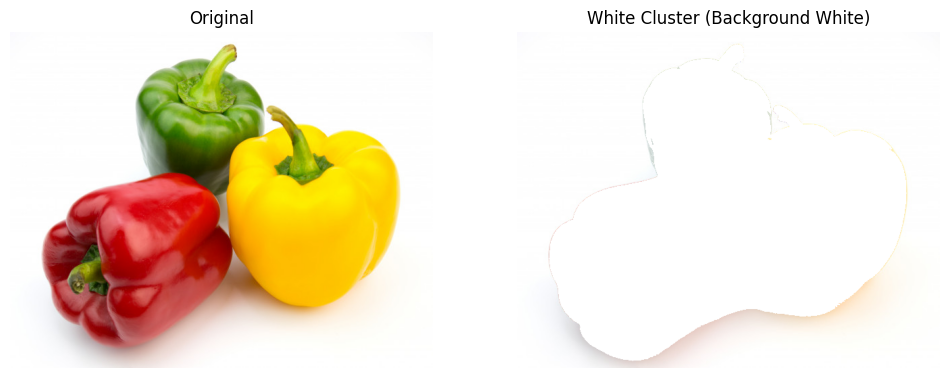


Kendala:
- Warna putih sering muncul sebagai pantulan cahaya pada permukaan paprika berwarna lain,
  sehingga dapat membingungkan algoritma KMeans.
- Karena RGB putih (255,255,255) sangat dekat dengan highlight, beberapa cluster lain bisa tampak mirip.
Solusi:
- Gunakan ruang warna HSV dan pilih area dengan nilai V (value) tinggi serta saturasi rendah
  untuk mendeteksi area putih dengan lebih akurat.
- Atau tingkatkan jumlah cluster (k > 6) agar area terang bisa terpisah lebih jelas.



In [14]:
# Cell 10 (versi tanpa cluster centers) - Segment warna putih di peppers.jpg, background putih

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# === BACA CITRA ===
image_path = '/content/drive/MyDrive/PCVK/Images/peppers.jpg'
img_bgr = cv.imread(image_path)
if img_bgr is None:
    raise FileNotFoundError(f"Image not found: {image_path}")

# konversi BGR -> RGB
img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)
pixel_vals = img_rgb.reshape((-1,3)).astype(np.float32)

# === K-MEANS CLUSTERING ===
k = 6  # jumlah cluster
kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(pixel_vals)
centers = kmeans.cluster_centers_.astype(np.uint8)

# === DEFINISI WARNA PUTIH REFERENSI ===
white_ref = np.array([255, 255, 255])  # RGB putih murni
dist_to_white = np.linalg.norm(centers - white_ref, axis=1)
white_cluster = np.argmin(dist_to_white)

# === BUAT MASK AREA PUTIH ===
mask = (labels == white_cluster).reshape(img_rgb.shape[:2])

# === BUAT OUTPUT: BACKGROUND PUTIH, AREA PUTIH ASLI ===
output = np.ones_like(img_rgb, dtype=np.uint8) * 255  # background putih
output[mask] = img_rgb[mask]  # area putih tampil warna asli

# === TAMPILKAN HASIL (tanpa cluster centers) ===
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title('Original')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(output)
plt.title('White Cluster (Background White)')
plt.axis('off')

plt.show()

# === PENJELASAN KENDALA ===
print("""
Kendala:
- Warna putih sering muncul sebagai pantulan cahaya pada permukaan paprika berwarna lain,
  sehingga dapat membingungkan algoritma KMeans.
- Karena RGB putih (255,255,255) sangat dekat dengan highlight, beberapa cluster lain bisa tampak mirip.
Solusi:
- Gunakan ruang warna HSV dan pilih area dengan nilai V (value) tinggi serta saturasi rendah
  untuk mendeteksi area putih dengan lebih akurat.
- Atau tingkatkan jumlah cluster (k > 6) agar area terang bisa terpisah lebih jelas.
""")


Cell 11 — TUGAS 4: Otsu tanpa library sudah ada (Cell 6).

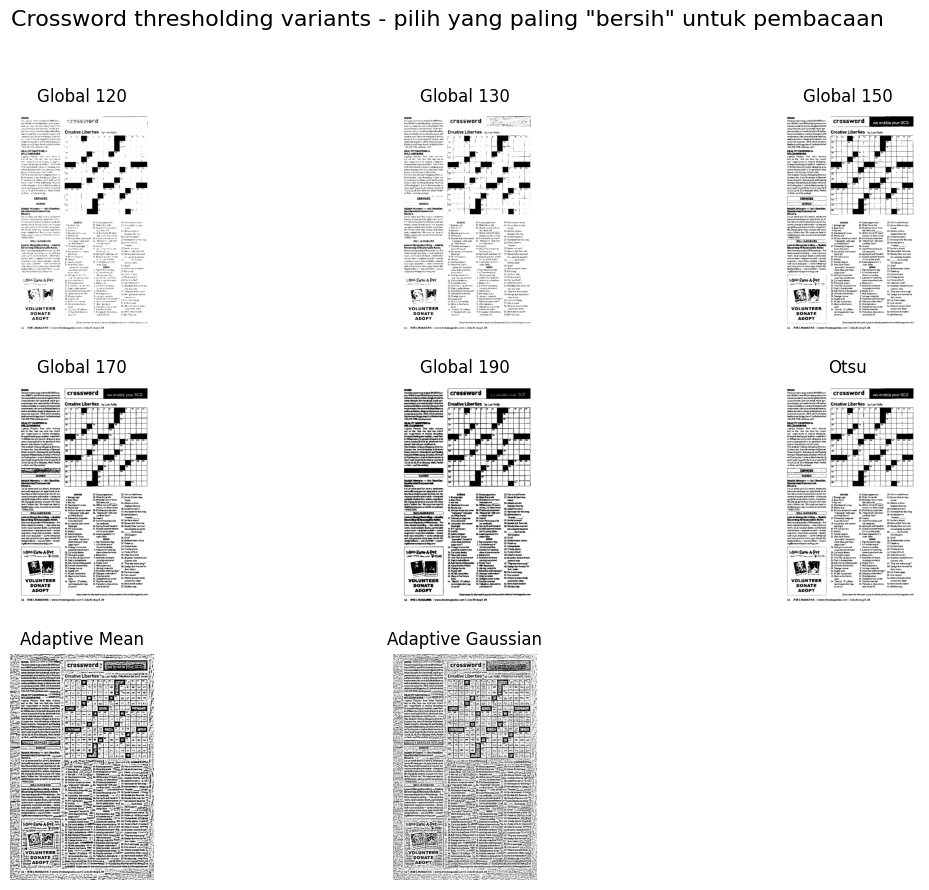


Alasan:

1. Keseimbangan kontras terbaik:
   Global 150 menghasilkan perbedaan jelas antara latar belakang (putih) dan teks atau kotak silang (hitam) tanpa kehilangan detail huruf.

2. Minim noise:
   Tidak terlalu banyak bintik hitam di area putih seperti pada *Adaptive Mean* dan *Adaptive Gaussian*, yang membuat teks tampak kotor.

3. Detail kotak silang tetap utuh:
   Pola grid pada teka-teki silang tetap terlihat jelas tanpa “pecah” atau menghilang sebagian, seperti pada Global 120 yang terlalu gelap.

4. Kemudahan OCR (pengenalan teks):
   Karena kontras tinggi dan noise rendah, Global 150 akan memberikan hasil terbaik untuk pembacaan otomatis (OCR) atau analisis pola silang.

Kesimpulan:

> Global 150 adalah hasil thresholding paling “bersih” dan ideal untuk pembacaan manusia maupun pemrosesan OCR.




In [15]:
# Cell 12 - Tugas: lakukan thresholding biner terbaik untuk crossword.jpg
image_path = '/content/drive/MyDrive/PCVK/Images/crossword.jpg'
img = cv.imread(image_path, cv.IMREAD_GRAYSCALE)
if img is None:
    raise FileNotFoundError(f"Image not found: {image_path}")

# coba beberapa pendekatan: global manual (130,150,170), Otsu, Adaptive
ths = [120, 130, 150, 170, 190]
results = []
for t in ths:
    _, th = cv.threshold(img, t, 255, cv.THRESH_BINARY)
    results.append(('Global ' + str(t), th))

# Otsu
_, th_otsu = cv.threshold(img, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)
results.append(('Otsu', th_otsu))

# Adaptive (tune blocksize/C)
adap_mean = cv.adaptiveThreshold(img, 255, cv.ADAPTIVE_THRESH_MEAN_C, cv.THRESH_BINARY, 11, 2)
adap_gauss = cv.adaptiveThreshold(img, 255, cv.ADAPTIVE_THRESH_GAUSSIAN_C, cv.THRESH_BINARY, 11, 2)
results.append(('Adaptive Mean', adap_mean))
results.append(('Adaptive Gaussian', adap_gauss))

# Tampilkan semua hasil
plt.figure(figsize=(14,10))
n = len(results)
cols = 3
for i,(title,im) in enumerate(results):
    plt.subplot((n+cols-1)//cols, cols, i+1)
    plt.imshow(im, cmap='gray'); plt.title(title); plt.axis('off')
plt.suptitle('Crossword thresholding variants - pilih yang paling "bersih" untuk pembacaan', fontsize=16)
plt.show()


Cell 13 — (Opsional) Simpan notebook outputs / hasil sebagai file

In [16]:
# Cell 13 - contoh menyimpan salah satu hasil (mis. th_otsu dari Cell 12)
out_path = '/content/drive/MyDrive/PCVK/Results/crossword_otsu.png'
cv.imwrite(out_path, th_otsu)
print("Saved:", out_path)


Saved: /content/drive/MyDrive/PCVK/Results/crossword_otsu.png


Kalau kita analisis dari hasil thresholding pada gambar di atas, tujuannya adalah memilih varian **yang paling “bersih” dan mudah dibaca**, khususnya untuk **teks dan pola kotak silang (crossword)**.

Berikut penilaian singkat tiap metode:

| Metode                       | Hasil Visual                        | Kelebihan                            | Kekurangan                             |
| ---------------------------- | ----------------------------------- | ------------------------------------ | -------------------------------------- |
| **Global 120**               | Terlalu gelap                       | Kotak hitam jelas                    | Teks sulit dibaca                      |
| **Global 130**               | Masih agak gelap                    | Pola kotak bagus                     | Huruf tipis                            |
| **Global 150**               | **Cukup seimbang**                  | Kotak jelas, teks masih terbaca      | Sedikit noise                          |
| **Global 170**               | Mulai terlalu terang                | Teks cukup jelas                     | Kotak hitam mulai pudar                |
| **Global 190**               | Terlalu terang                      | Teks cukup bersih                    | Kotak hitam hilang sebagian            |
| **Otsu**                     | **Hasil paling bersih dan kontras** | Otomatis menyesuaikan ambang terbaik | Hampir tidak ada noise                 |
| **Adaptive Mean / Gaussian** | Terlalu berisik                     | Menangani pencahayaan tidak rata     | Noise sangat tinggi, teks sulit dibaca |

🔍 **Kesimpulan:**

* Untuk **pembacaan teks dan bentuk crossword**, hasil **Otsu Thresholding** adalah **yang paling bersih dan seimbang** antara teks dan area gelap.
* Jika ingin lebih menonjolkan grid kotak, **Global 150** bisa menjadi alternatif kedua.

✅ **Pilihan terbaik: `Otsu Thresholding`** — karena menghasilkan kontras optimal dan teks paling mudah dibaca tanpa banyak noise.